# Batch 1 — Evaluation

Loads the trained models and `batch1_results.csv` from `training.ipynb`,
compares them on the **validation set** (test set stays untouched), and
checks for overfitting, CV stability, and recall/precision trade-offs
before deciding what Batch 2 should try.


In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')


## 1. Paths & Load Results

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Models_Batch_1' else Path.cwd()
BATCH_DIR = PROJECT_ROOT / 'Models_Batch_1'
ARTIFACTS_DIR = BATCH_DIR / 'artifacts'
MODELS_DIR = ARTIFACTS_DIR / 'models'
FIGURES_DIR = BATCH_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

data = joblib.load(ARTIFACTS_DIR / 'batch1_data.joblib')
results_df = pd.read_csv(ARTIFACTS_DIR / 'batch1_results.csv')
y_val = data['y_val']

print(f"Loaded {len(results_df)} model results")
results_df[['Model', 'Feature_Set', 'CV_PR_AUC', 'Validation_PR_AUC', 'Precision', 'Recall', 'F1', 'ROC_AUC']]


Loaded 10 model results


,Model,Feature_Set,CV_PR_AUC,Validation_PR_AUC,Precision,Recall,F1,ROC_AUC
0,CatBoost,catboost_native,0.8041,0.8051,0.9181,0.5995,0.7254,0.9314
1,XGBoost,tree,0.8037,0.8039,0.9079,0.6132,0.7320,0.9293
2,LightGBM,tree,0.8006,0.8008,0.9015,0.6144,0.7308,0.9291
3,MLP,rob,0.7891,0.7804,0.8932,0.6032,0.7201,0.9079
4,RandomForest,tree,0.7809,0.7724,0.9302,0.5137,0.6619,0.9140
5,DecisionTree,tree,0.7475,0.7585,0.9260,0.5759,0.7101,0.9004
6,SVM,rob,0.7708,0.7288,0.8642,0.5460,0.6692,0.8841
7,LogisticRegression_rob,rob,0.7255,0.7087,0.8775,0.4366,0.5831,0.8889
8,LogisticRegression_std,std,0.7242,0.7076,0.8784,0.4403,0.5866,0.8883
9,NaiveBayes,tree,0.4342,0.4419,0.6233,0.2799,0.3863,0.7708


## 2. Load Trained Models & Get Validation Predictions

Each model was saved with the feature set it was trained/evaluated on.


In [3]:
FEATURE_SET_MAP = {
    'tree': 'X_val_tree',
    'catboost_native': 'X_val_cb',
    'std': 'X_val_std',
    'rob': 'X_val_rob',
}

model_names = results_df['Model'].tolist()
models = {}
val_proba = {}
val_pred = {}

for _, row in results_df.iterrows():
    name = row['Model']
    model = joblib.load(MODELS_DIR / f'{name}.joblib')
    X_val_key = FEATURE_SET_MAP[row['Feature_Set']]
    X_val = data[X_val_key]
    proba = model.predict_proba(X_val)[:, 1]
    models[name] = model
    val_proba[name] = proba
    val_pred[name] = (proba >= 0.5).astype(int)

print("Loaded models:", list(models.keys()))


Loaded models: ['CatBoost', 'XGBoost', 'LightGBM', 'MLP', 'RandomForest', 'DecisionTree', 'SVM', 'LogisticRegression_rob', 'LogisticRegression_std', 'NaiveBayes']


## 3. Overfitting Check — CV vs Validation PR-AUC

If validation PR-AUC is much *lower* than CV PR-AUC, the model overfit the
training folds. If validation is much *higher*, that's usually a sign the
validation fold happens to be easier, or CV had high variance — either way,
a large gap in either direction is worth flagging rather than trusting the
single validation number blindly.


In [4]:
overfit_df = results_df[['Model', 'CV_PR_AUC', 'CV_PR_AUC_std', 'Validation_PR_AUC']].copy()
overfit_df['Gap (Val - CV)'] = (overfit_df['Validation_PR_AUC'] - overfit_df['CV_PR_AUC']).round(4)
overfit_df = overfit_df.sort_values('Gap (Val - CV)')
overfit_df


,Model,CV_PR_AUC,CV_PR_AUC_std,Validation_PR_AUC,Gap (Val - CV)
6,SVM,0.7708,0.0211,0.7288,-0.0420
7,LogisticRegression_rob,0.7255,0.0131,0.7087,-0.0168
8,LogisticRegression_std,0.7242,0.0134,0.7076,-0.0166
3,MLP,0.7891,0.0116,0.7804,-0.0087
4,RandomForest,0.7809,0.0125,0.7724,-0.0085
1,XGBoost,0.8037,0.0147,0.8039,0.0002
2,LightGBM,0.8006,0.0140,0.8008,0.0002
0,CatBoost,0.8041,0.0150,0.8051,0.0010
9,NaiveBayes,0.4342,0.0179,0.4419,0.0077
5,DecisionTree,0.7475,0.0163,0.7585,0.0110


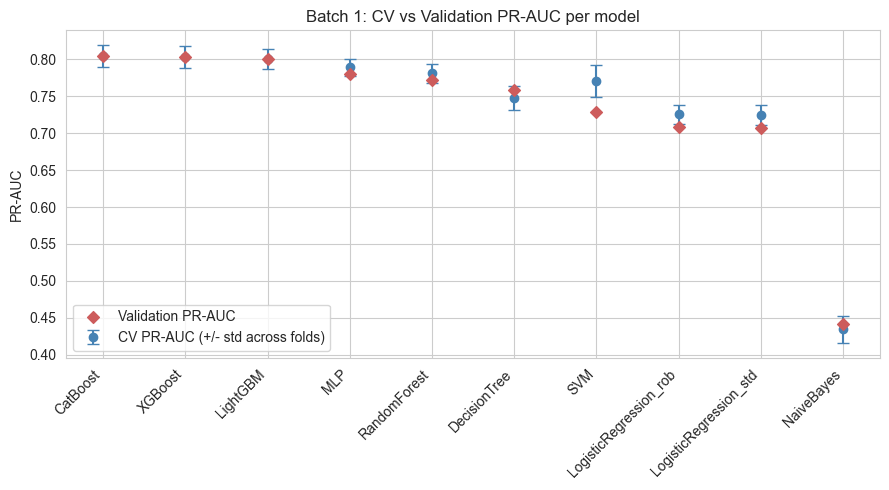

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results_df))
ax.errorbar(x, results_df['CV_PR_AUC'], yerr=results_df['CV_PR_AUC_std'],
            fmt='o', label='CV PR-AUC (+/- std across folds)', capsize=4, color='steelblue')
ax.scatter(x, results_df['Validation_PR_AUC'], marker='D', color='indianred', label='Validation PR-AUC', zorder=5)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.set_ylabel('PR-AUC')
ax.set_title('Batch 1: CV vs Validation PR-AUC per model')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_vs_validation_pr_auc.png', dpi=120)
plt.show()


## 4. Confusion Matrices (Validation Set, threshold = 0.5)

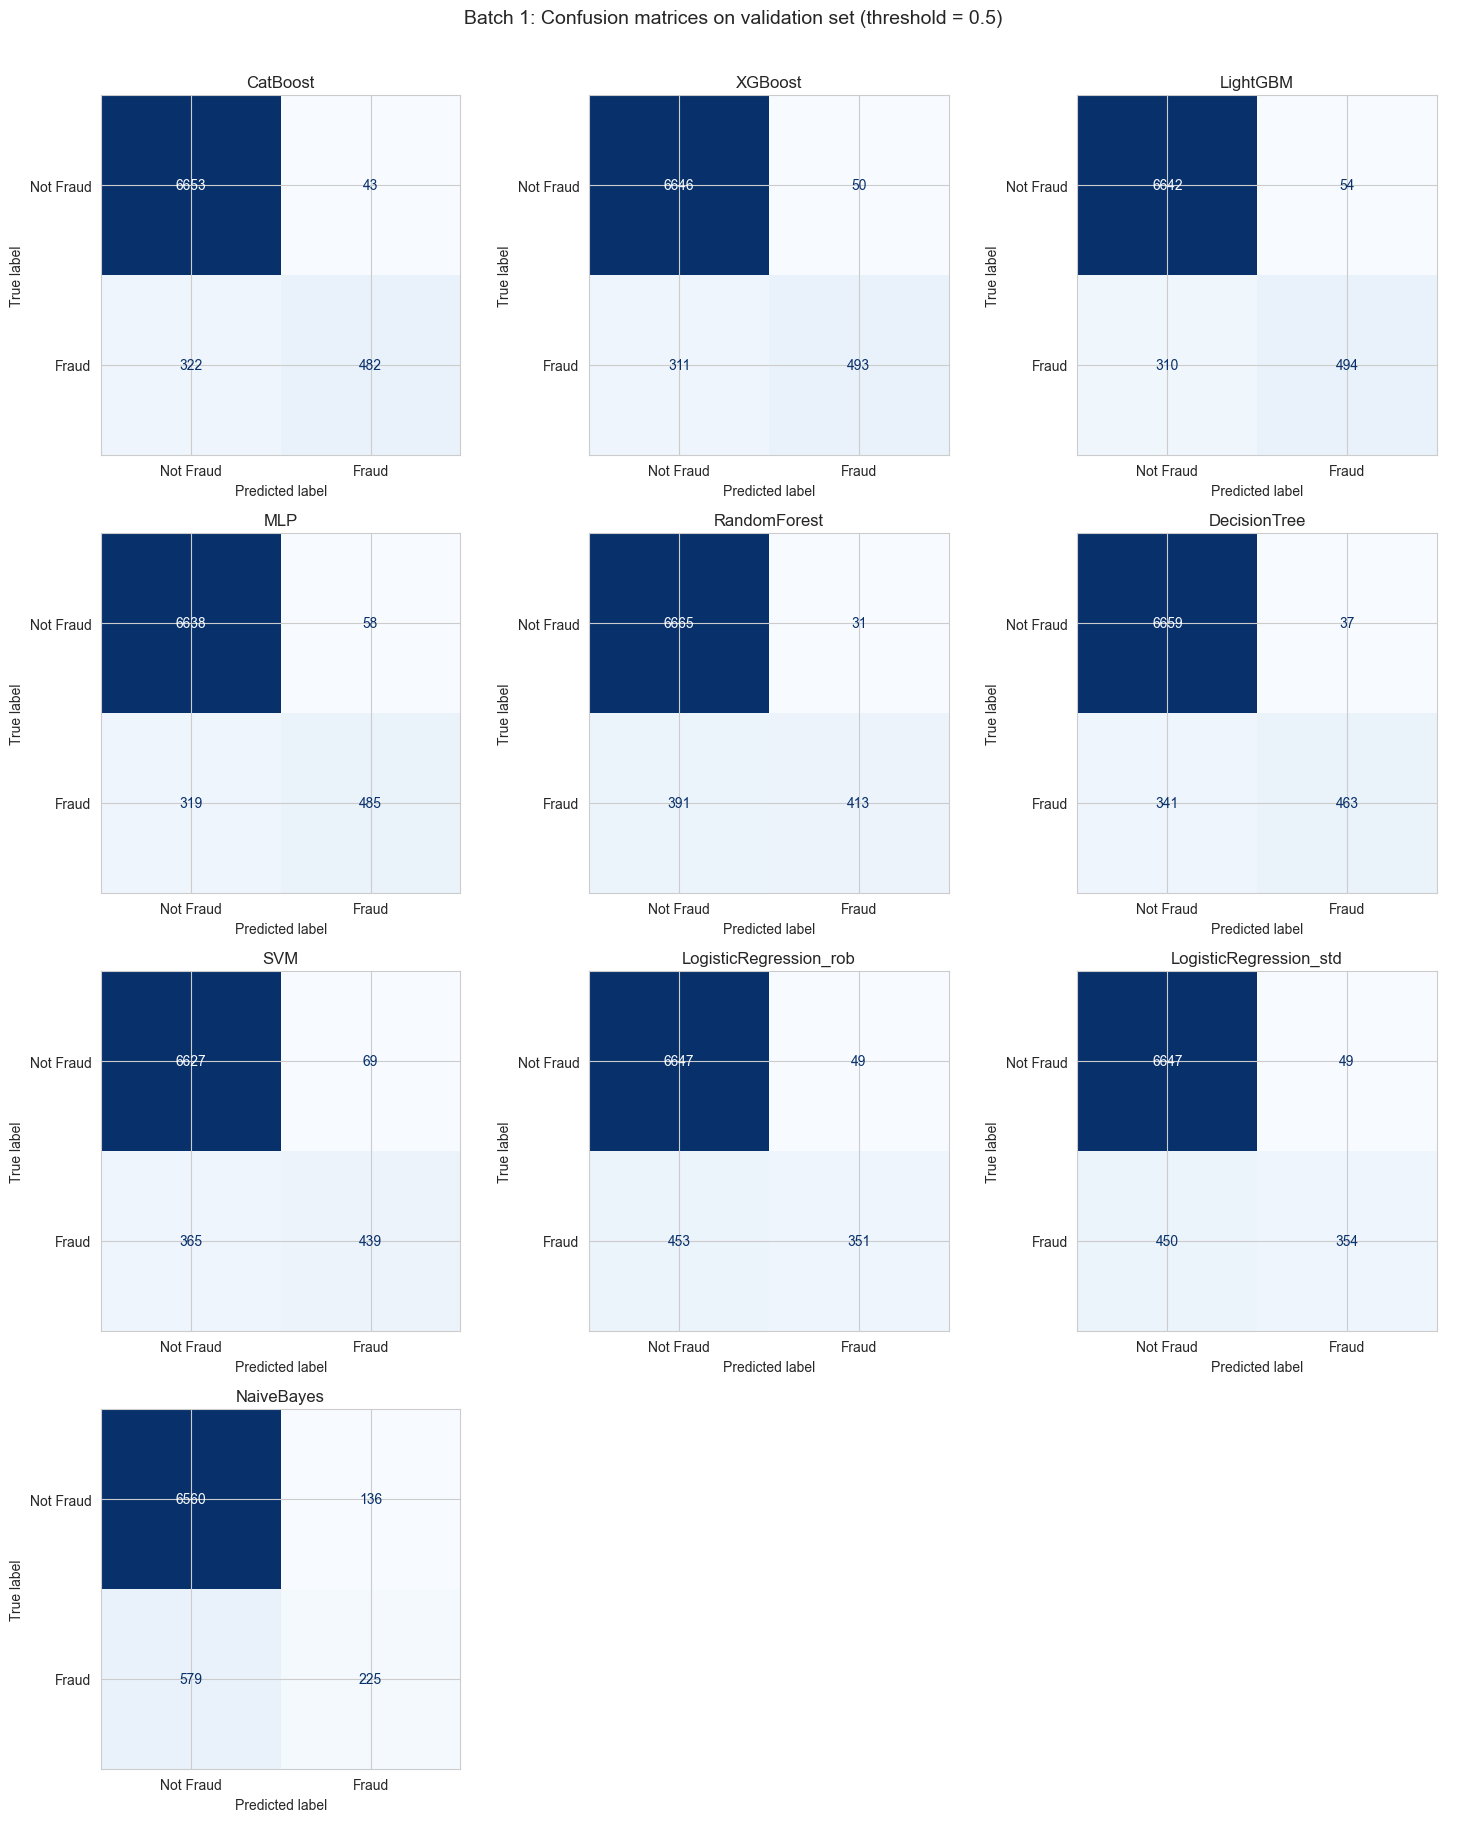

In [6]:
n_models = len(model_names)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.flatten()

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_val, val_pred[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name)

for ax in axes[len(model_names):]:
    ax.axis('off')

plt.suptitle('Batch 1: Confusion matrices on validation set (threshold = 0.5)', y=1.01, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


## 5. ROC Curves (All Models Overlaid)

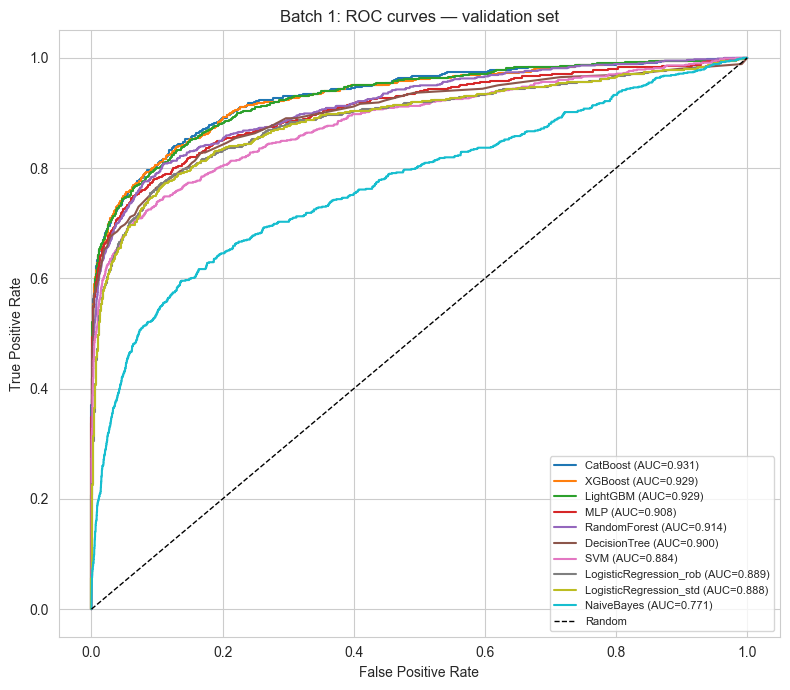

In [7]:
plt.figure(figsize=(8, 7))
for name in model_names:
    fpr, tpr, _ = roc_curve(y_val, val_proba[name])
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Batch 1: ROC curves — validation set')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curves.png', dpi=120)
plt.show()


## 6. Precision-Recall Curves (All Models Overlaid)

This is the more informative curve for an imbalanced target like fraud —
ROC-AUC can look deceptively good even for weak models when negatives vastly
outnumber positives, since the false-positive rate denominator is huge.


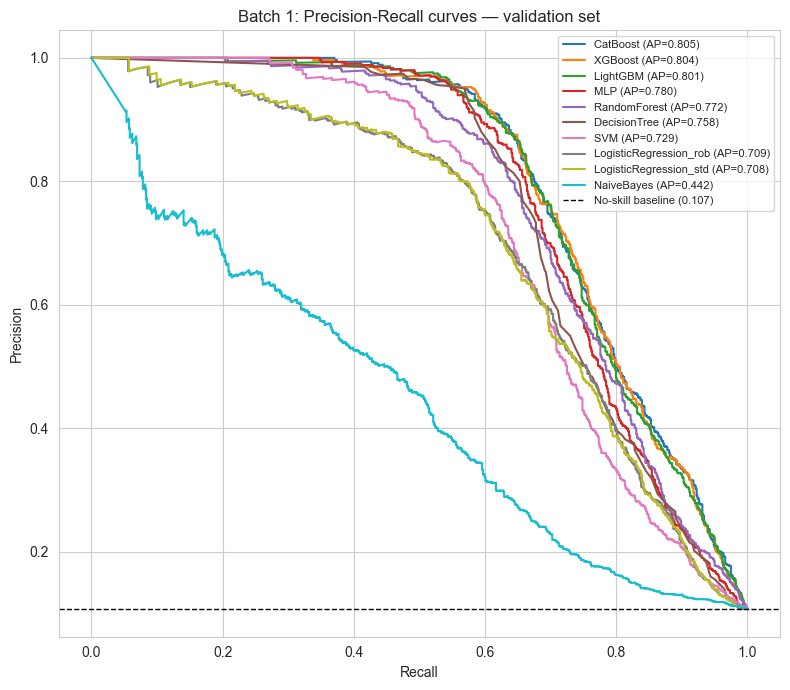

In [8]:
plt.figure(figsize=(8, 7))
baseline_rate = y_val.mean()
for name in model_names:
    precision, recall, _ = precision_recall_curve(y_val, val_proba[name])
    pr_auc = average_precision_score(y_val, val_proba[name])
    plt.plot(recall, precision, label=f'{name} (AP={pr_auc:.3f})')
plt.axhline(baseline_rate, color='k', linestyle='--', linewidth=1, label=f'No-skill baseline ({baseline_rate:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Batch 1: Precision-Recall curves — validation set')
plt.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pr_curves.png', dpi=120)
plt.show()


## 7. Recall / Precision Balance at the Default Threshold

In [9]:
balance_df = results_df[['Model', 'Precision', 'Recall', 'F1', 'Validation_PR_AUC', 'ROC_AUC']].sort_values(
    'Validation_PR_AUC', ascending=False
)
balance_df


,Model,Precision,Recall,F1,Validation_PR_AUC,ROC_AUC
0,CatBoost,0.9181,0.5995,0.7254,0.8051,0.9314
1,XGBoost,0.9079,0.6132,0.7320,0.8039,0.9293
2,LightGBM,0.9015,0.6144,0.7308,0.8008,0.9291
3,MLP,0.8932,0.6032,0.7201,0.7804,0.9079
4,RandomForest,0.9302,0.5137,0.6619,0.7724,0.9140
5,DecisionTree,0.9260,0.5759,0.7101,0.7585,0.9004
6,SVM,0.8642,0.5460,0.6692,0.7288,0.8841
7,LogisticRegression_rob,0.8775,0.4366,0.5831,0.7087,0.8889
8,LogisticRegression_std,0.8784,0.4403,0.5866,0.7076,0.8883
9,NaiveBayes,0.6233,0.2799,0.3863,0.4419,0.7708


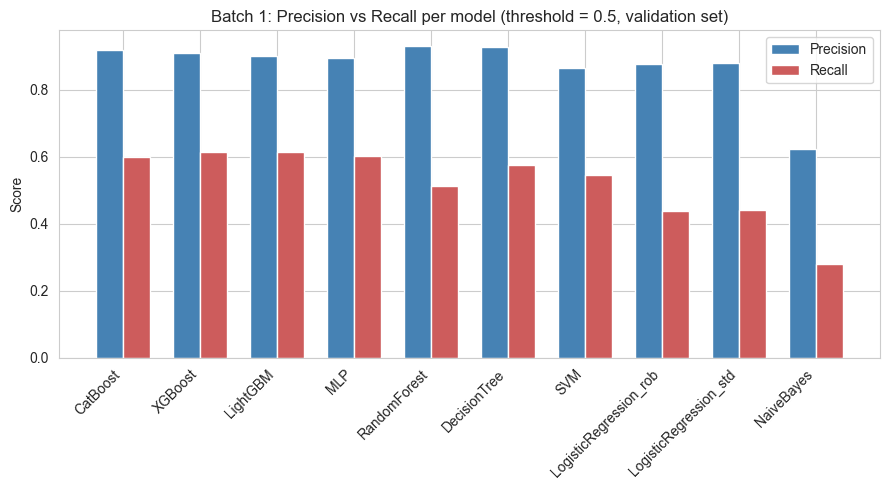

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(balance_df))
width = 0.35
ax.bar(x - width/2, balance_df['Precision'], width, label='Precision', color='steelblue')
ax.bar(x + width/2, balance_df['Recall'], width, label='Recall', color='indianred')
ax.set_xticks(x)
ax.set_xticklabels(balance_df['Model'], rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Batch 1: Precision vs Recall per model (threshold = 0.5, validation set)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'precision_recall_balance.png', dpi=120)
plt.show()


## 8. Feature Importance (Best Tree-Based Model)

Sanity check against the EDA findings: does the strongest model actually
lean on `Tax_Gap` and the behavioral flags the way we expected?


Best tree-based model: CatBoost


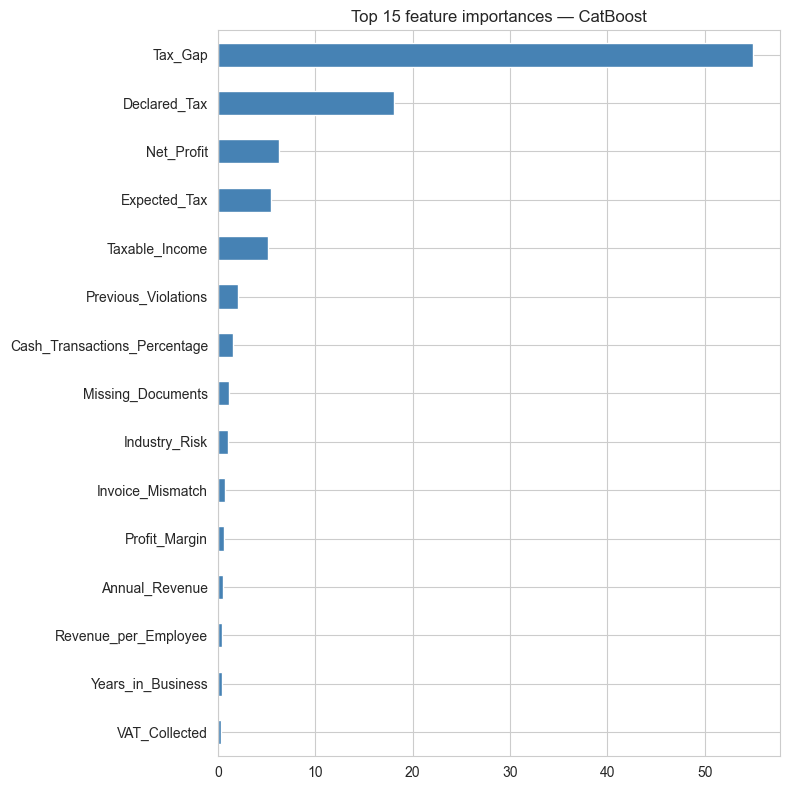

In [11]:
tree_models = results_df[results_df['Feature_Set'].isin(['tree', 'catboost_native'])].sort_values(
    'Validation_PR_AUC', ascending=False
)
best_tree_name = tree_models.iloc[0]['Model']
best_tree_model = models[best_tree_name]
print(f"Best tree-based model: {best_tree_name}")

if hasattr(best_tree_model, 'feature_importances_'):
    if best_tree_name == 'CatBoost':
        feat_names = data['X_train_cb'].columns.tolist()
    else:
        feat_names = data['tree_feature_names']
    importances = pd.Series(best_tree_model.feature_importances_, index=feat_names).sort_values(ascending=False)

    plt.figure(figsize=(8, 8))
    importances.head(15).plot(kind='barh', color='steelblue')
    plt.gca().invert_yaxis()
    plt.title(f'Top 15 feature importances — {best_tree_name}')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'feature_importance.png', dpi=120)
    plt.show()

    importances.head(15)


## 9. Update the Master Comparison Table

In [12]:
master_path = RESULTS_DIR / 'comparison_table.csv'

if master_path.exists():
    master_df = pd.read_csv(master_path)
    master_df = master_df[master_df['Batch'] != 'Batch_1']  # replace any prior Batch_1 rows
    master_df = pd.concat([master_df, results_df], ignore_index=True)
else:
    master_df = results_df.copy()

master_df.to_csv(master_path, index=False)
print(f"Master comparison table now has {len(master_df)} rows across all batches so far.")
master_df[master_df['Batch'] == 'Batch_1'][['Model', 'CV_PR_AUC', 'Validation_PR_AUC', 'Precision', 'Recall', 'F1']]


Master comparison table now has 10 rows across all batches so far.


,Model,CV_PR_AUC,Validation_PR_AUC,Precision,Recall,F1
0,CatBoost,0.8041,0.8051,0.9181,0.5995,0.7254
1,XGBoost,0.8037,0.8039,0.9079,0.6132,0.7320
2,LightGBM,0.8006,0.8008,0.9015,0.6144,0.7308
3,MLP,0.7891,0.7804,0.8932,0.6032,0.7201
4,RandomForest,0.7809,0.7724,0.9302,0.5137,0.6619
5,DecisionTree,0.7475,0.7585,0.9260,0.5759,0.7101
6,SVM,0.7708,0.7288,0.8642,0.5460,0.6692
7,LogisticRegression_rob,0.7255,0.7087,0.8775,0.4366,0.5831
8,LogisticRegression_std,0.7242,0.7076,0.8784,0.4403,0.5866
9,NaiveBayes,0.4342,0.4419,0.6233,0.2799,0.3863


## 10. Batch 1 Analysis & Hypothesis for Batch 2

### Strongest / weakest models

**Gradient boosting wins, but by a small and probably not significant margin.**
CatBoost (0.8051), XGBoost (0.8039), and LightGBM (0.8008) validation PR-AUC
are within ~0.005 of each other — smaller than each model's own CV
fold-to-fold standard deviation (~0.014-0.015). They should be treated as
**tied**, not "CatBoost wins."

**CatBoost's cost does not match its marginal edge.** It took **1,518s
(~25 min)** to tune — **22x longer than LightGBM (69s)** and **28x longer
than XGBoost (55s)** — for a PR-AUC that is not meaningfully different.
Unless CatBoost's native categorical handling proves valuable in a way that
shows up later (e.g. more stable under a different feature set in Batch 2),
LightGBM or XGBoost are the more practical choice.

**Naive Bayes is far behind everything else** (PR-AUC 0.442 vs ~0.70-0.80
for every other model). This is expected: `GaussianNB` assumes features are
independent and normally distributed, and this dataset violates both
(financial columns are skewed and — as the feature importance plot below
shows — several are near-duplicates of each other). It's kept in the
comparison table as required, but isn't a serious candidate.

**Random Forest underperforms the boosted trees** (0.7724 vs ~0.80) despite
being closely related — and it was also the second-slowest model to tune
(426s). Un-boosted bagged trees apparently can't capture the same
signal as well here; not worth its training cost relative to XGBoost/LightGBM.

### Overfitting check (CV PR-AUC vs Validation PR-AUC)

No model shows meaningful overfitting. Every CV-vs-validation gap is within
±0.02, and the boosted-tree models (CatBoost, XGBoost, LightGBM) have gaps
under 0.001 — remarkably stable. The one outlier is **SVM (gap = -0.042)**,
where validation PR-AUC (0.729) is notably lower than its CV PR-AUC (0.771).
This is most likely explained by SVM being tuned on only a 6,000-row
subsample with 3-fold CV (~2,000 rows/fold) — small enough that CV estimates
have real variance (its CV std, 0.0211, is also the highest of any model).
Not evidence of a bad model, just evidence that the subsampling compromise
documented in `training.ipynb` has a real cost in estimate precision.

### Precision / recall balance — the central finding for Batch 2

At the default 0.5 threshold, **every single model is precision-heavy and
recall-starved**: the best models sit around 90% precision but only
~60% recall. Concretely, CatBoost/XGBoost/LightGBM only catch **~60% of
actual fraud cases** — the other 40% are false negatives. The PR curves
above show why: precision stays near-1.0 out to about 50-60% recall, then
drops sharply — meaning the "easy" fraud cases (large `Tax_Gap`, obvious
violations) are being caught reliably, but pushing further to catch the
harder cases costs a lot of precision.

For a fraud-screening system, missing 40% of fraud is a significant
practical problem — **this is exactly the gap Batch 2's imbalance
experiments (class weights / SMOTE / other sampling) are meant to close**,
and PR-AUC / precision must be watched closely to see whether recall gains
come at an acceptable cost.

### Feature importance confirms — and sharpens — the EDA/multicollinearity concern

CatBoost's feature importances are heavily concentrated: **`Tax_Gap` alone
accounts for ~55% of total importance**, and **`Declared_Tax` for another
~18%** — together with `Expected_Tax` and `Taxable_Income` (~5% each), the
`Tax_Gap`/`Expected_Tax`/`Declared_Tax`/`Taxable_Income` cluster accounts for
roughly **83% of everything the model relies on**. Every other signal EDA
flagged as meaningful — `Previous_Violations`, `Cash_Transactions_Percentage`,
`Missing_Documents`, `Industry_Risk`, `Invoice_Mismatch` — each contributes
only 1-2%, even though EDA showed they *do* separate fraud from non-fraud on
their own.

This is precisely the risk flagged in `EDA.ipynb` and `processing.ipynb`:
`Tax_Gap` is *literally* `Expected_Tax - Declared_Tax`, so having all three
columns present lets the model lean almost entirely on one redundant
cluster. It hasn't hurt Batch 1's raw metrics (no overfitting was observed),
but it raises a real question for Batch 2: **does removing the
mathematically redundant duplicates (keeping `Tax_Gap`, dropping
`Expected_Tax`/`Declared_Tax`; resolving `Expense_Ratio` vs `Profit_Margin`;
etc.) force the model to make better use of the behavioral features, and
does that change recall/precision/PR-AUC for better or worse?**

### CV stability

Every model's CV PR-AUC standard deviation is small (0.012-0.018) except
SVM (0.021, explained above) — the 5-fold CV results are stable and
trustworthy across the board.

---

### Hypothesis for Batch 2

**What changed (planned):**
1. Test class weights, SMOTE, random oversampling, random undersampling,
   and combined sampling (SMOTEENN / SMOTETomek) — applied only within
   training folds / on the training split, never on validation or test —
   to see whether the ~60% recall ceiling observed here can be pushed
   higher.
2. Run VIF analysis on the financial feature block and formally evaluate
   removing the mathematically redundant columns identified in EDA and
   confirmed by this batch's feature importances (`Expected_Tax`,
   `Declared_Tax` vs `Tax_Gap`; `Expense_Ratio` vs `Profit_Margin`; the
   `VAT_Collected`/`VAT_Paid` vs `Annual_Revenue`/`Annual_Expenses` pairs).
3. Focus the comparison on the three models that tied for best
   (CatBoost, XGBoost, LightGBM) plus Logistic Regression, since Logistic
   Regression is the model most sensitive to multicollinearity and gives
   the clearest read on whether redundancy removal helps a linear model
   specifically.

**Expected result:** recall should improve with class weighting / SMOTE,
at some precision cost — the open question is whether PR-AUC net improves
or just shifts the precision/recall trade-off along the same curve.
Redundant-feature removal is expected to have a small effect on raw
performance (the model already isn't overfitting) but should make the
surviving behavioral features carry more relative importance, which matters
for interpretability and robustness even if PR-AUC barely moves.

**What should change next:** Batch 2 will report, per experiment, whether
each change actually improved CV/validation PR-AUC — including if it
didn't (e.g. "SMOTE increased recall but reduced precision and did not
improve PR-AUC" is an acceptable, expected kind of finding, not a failure
to hide).
